In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("AusApparalSales4thQrt2020.csv")

In [3]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


In [5]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [6]:
df.notna().sum()

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

In [7]:
df = df.dropna()

In [8]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='str')

In [11]:
scaler = MinMaxScaler()

df[['Sales', 'Unit']] = scaler.fit_transform(df[['Sales', 'Unit']])

df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873


In [12]:
print("Mean")
print(df[['Sales', 'Unit']].mean())

print("\nMedian")
print(df[['Sales', 'Unit']].median())

print("\nMode")
print(df[['Sales', 'Unit']].mode())

print("\nStandard Deviation")
print(df[['Sales', 'Unit']].std())

Mean
Sales    0.254054
Unit     0.254054
dtype: float64

Median
Sales    0.190476
Unit     0.190476
dtype: float64

Mode
      Sales      Unit
0  0.111111  0.111111

Standard Deviation
Sales    0.204784
Unit     0.204784
dtype: float64


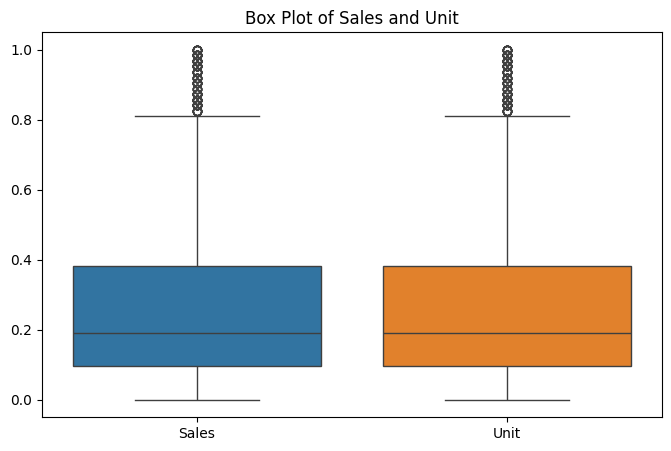

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[['Sales', 'Unit']])

plt.title("Box Plot of Sales and Unit")

plt.show()

In [14]:
state_sales = df.groupby('State')['Sales'].sum()

state_sales

State
NSW    441.714286
NT     109.079365
QLD    177.888889
SA     339.412698
TAS    110.222222
VIC    635.968254
WA     106.365079
Name: Sales, dtype: float64

In [15]:
print("Mean")
print(df[['Sales', 'Unit']].mean())

print("\nMedian")
print(df[['Sales', 'Unit']].median())

print("\nMode")
print(df[['Sales', 'Unit']].mode())

print("\nStandard Deviation")
print(df[['Sales', 'Unit']].std())

Mean
Sales    0.254054
Unit     0.254054
dtype: float64

Median
Sales    0.190476
Unit     0.190476
dtype: float64

Mode
      Sales      Unit
0  0.111111  0.111111

Standard Deviation
Sales    0.204784
Unit     0.204784
dtype: float64


In [16]:
highest_sales = df.groupby('State')['Sales'].sum().idxmax()

print("Highest Sales State:", highest_sales)

Highest Sales State:  VIC


In [17]:
lowest_sales = df.groupby('State')['Sales'].sum().idxmin()

print("Lowest Sales State:", lowest_sales)

Lowest Sales State:  WA


In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
weekly_report = df.groupby(pd.Grouper(key='Date', freq='W'))['Sales'].sum()

weekly_report

Date
2020-10-04     84.857143
2020-10-11    152.777778
2020-10-18    150.476190
2020-10-25    151.587302
2020-11-01    122.460317
2020-11-08    113.809524
2020-11-15    115.761905
2020-11-22    115.380952
2020-11-29    117.698413
2020-12-06    169.412698
2020-12-13    181.492063
2020-12-20    182.317460
2020-12-27    183.047619
2021-01-03     79.571429
Freq: W-SUN, Name: Sales, dtype: float64

In [21]:
monthly_report = df.groupby(pd.Grouper(key='Date', freq='ME'))['Sales'].sum()

monthly_report

Date
2020-10-31    645.650794
2020-11-30    495.761905
2020-12-31    779.238095
Freq: ME, Name: Sales, dtype: float64

In [22]:
quarterly_report = df.groupby(pd.Grouper(key='Date', freq='QE'))['Sales'].sum()

quarterly_report

Date
2020-12-31    1920.650794
Freq: QE-DEC, Name: Sales, dtype: float64

In [23]:
quarterly_report = df.groupby(pd.Grouper(key='Date', freq='QE'))['Sales'].sum()

quarterly_report

Date
2020-12-31    1920.650794
Freq: QE-DEC, Name: Sales, dtype: float64

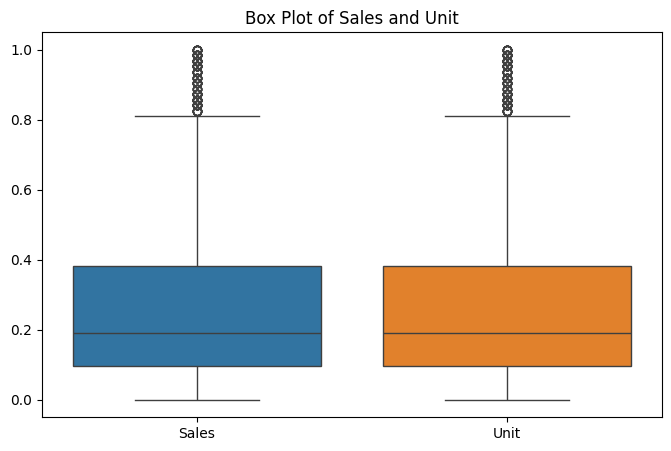

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[['Sales', 'Unit']])

plt.title("Box Plot of Sales and Unit")

plt.show()

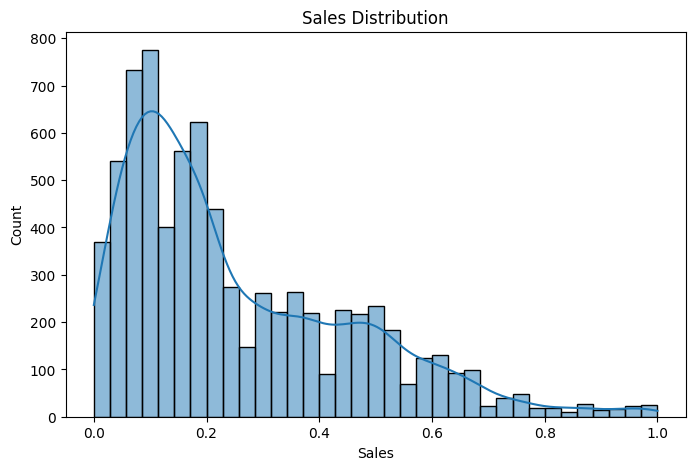

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], kde=True)

plt.title("Sales Distribution")

plt.show()

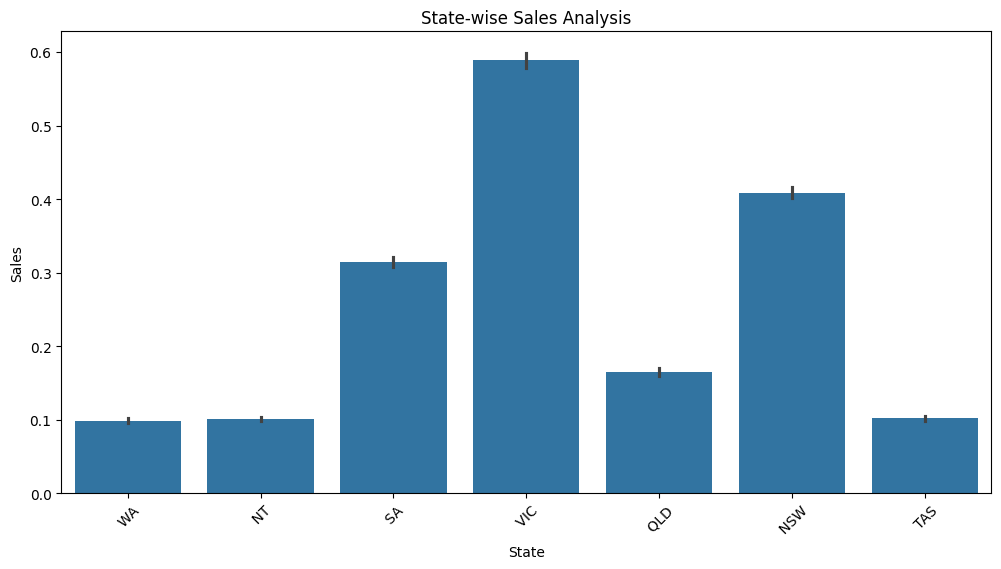

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(x='State', y='Sales', data=df)

plt.title("State-wise Sales Analysis")

plt.xticks(rotation=45)

plt.show()

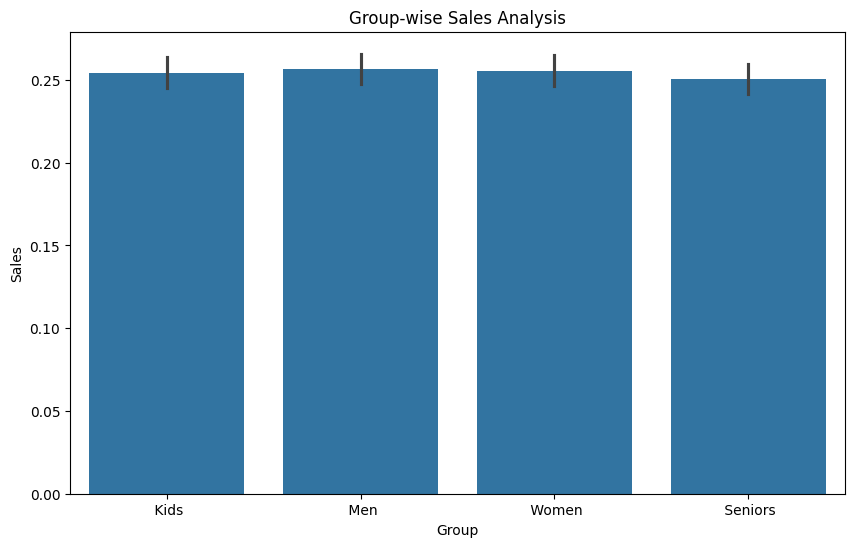

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(x='Group', y='Sales', data=df)

plt.title("Group-wise Sales Analysis")

plt.show()

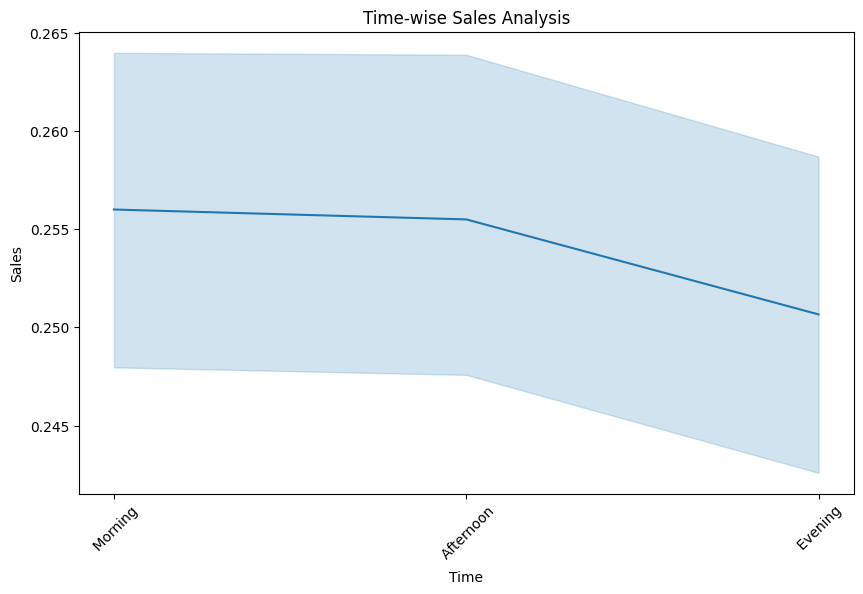

In [28]:
plt.figure(figsize=(10,6))

sns.lineplot(x='Time', y='Sales', data=df)

plt.title("Time-wise Sales Analysis")

plt.xticks(rotation=45)

plt.show()

# Sales Analysis Report

## Data Wrangling

## Data Analysis

## Data Visualization

## Conclusion

## Conclusion

- Highest sales state: Victoria
- Lowest sales state: Western Australia
- Sales analysis completed successfully.
- Seaborn was used because it provides powerful statistical visualizations and easy statistical plotting.